# 5 · Sensitivity-aware robust control under hidden confounding

**`chc.sensitivity` in one pass: estimate → sensitivity radius → robust control.** Offline pessimism
assumes the observed transitions *identify* the causal effect. Under **hidden confounding** they do
not — the effect is only partially identified in a sensitivity interval. This demo takes a confounded
marketplace log, shows the naive effect estimate is biased, turns an (unfalsifiable) sensitivity
`Gamma` into a pessimism radius (Result 32), and lets a **minimax controller** hedge the costlier
error under an asymmetric business cost (Result 35) — beating certainty-equivalence on the realised
cost (Result 37). Every step is machine-checked (Rocq/Maxima); see `discoveries/theorems.md` §32–§37.

In [1]:
import numpy as np

from chc.sensitivity import (
    asymmetric_control_improvement,
    certainty_equivalence_control,
    confounding_robust_control,
    confounding_robust_control_benchmark,
    confounding_robust_inflation,
    worst_case_asymmetric_loss,
)

rng = np.random.default_rng(0)

## 1 · The confounded log biases the naive effect

A demand shock `z` drives BOTH the historical incentive (`u = z + noise`; the past policy raised
incentives on busy periods) AND completions (`y = b_true·u + gamma·z + noise`; demand also lifts
completions directly). Regressing `y` on `u` ignoring `z` returns an effect biased **upward** — this
is *observational confounded logging*, not a randomised switchback experiment.

In [2]:
b_true, gamma_conf, action_noise, n = 2.0, 0.8, 0.6, 200_000
z = rng.standard_normal(n)
u = z + action_noise * rng.standard_normal(n)                    # incentive tracks demand
y = b_true * u + gamma_conf * z + action_noise * rng.standard_normal(n)  # ...and demand lifts completions
b_hat = float(np.cov(u, y)[0, 1] / np.var(u))                    # naive OLS: biased by the confounding
print(f"true effect b      = {b_true:.3f}")
print(f"naive OLS estimate = {b_hat:.3f}   (biased up by {b_hat - b_true:+.3f})")

true effect b      = 2.000
naive OLS estimate = 2.587   (biased up by +0.587)


## 2 · A sensitivity `Gamma` → a pessimism radius (Result 32)

Under a bounded density-ratio (marginal) sensitivity model the density-ratio weight lies in
`[1/Gamma, Gamma]`; the sharp worst-case effect is a CVaR mixture, and the gap over the point
estimate inflates the radius by `(Gamma-1)/(Gamma+1)·(CVaR gap)`. For this synthetic demo we
**calibrate** the CVaR gap to `b_hat` (an explicit assumption, keeping the half-width `D < b_hat` so
the effect *sign* stays identified). `Gamma=1` (no confounding assumed) gives `D=0`.

In [3]:
target = 1.0
for gamma in (1.0, 1.5, 2.5, 4.0):
    d = confounding_robust_inflation(b_hat, 0.0, gamma)  # cvar gap := b_hat (named calibration)
    print(f"Gamma = {gamma:>3}   half-width D = {d:.3f}   (D < b_hat = {d < b_hat})")

Gamma = 1.0   half-width D = 0.000   (D < b_hat = True)
Gamma = 1.5   half-width D = 0.517   (D < b_hat = True)
Gamma = 2.5   half-width D = 1.109   (D < b_hat = True)
Gamma = 4.0   half-width D = 1.552   (D < b_hat = True)


## 3 · CE vs the confounding-robust controller under asymmetric cost (Result 35)

The controller sets the incentive to hit a service target `target`. The business cost is
**asymmetric**: missing riders (churn) costs `4×` budget waste. The CE controller trusts the biased
`b_hat`, under-incentivises, and pays churn. The §35 minimax controller uses the radius `D` to shift
the gain UP (the sign dichotomy: undershoot costlier → be more aggressive) and hedges the churn.

In [4]:
gamma, overshoot_penalty, undershoot_penalty = 2.5, 1.0, 4.0  # churn 4x budget waste
d = confounding_robust_inflation(b_hat, 0.0, gamma)
u_ce = certainty_equivalence_control(b_hat, target)
u_rob = confounding_robust_control(b_hat, d, target, overshoot_penalty, undershoot_penalty)


def realised_cost(u: float) -> float:
    """Asymmetric business cost of applying control u, on the TRUE plant (y = b_true·u)."""
    y_real = b_true * u
    over = overshoot_penalty * max(0.0, y_real - target)
    under = undershoot_penalty * max(0.0, target - y_real)
    return over + under


print(f"u_CE     = {u_ce:.3f}   realised cost = {realised_cost(u_ce):.3f}")
print(f"u_robust = {u_rob:.3f}   realised cost = {realised_cost(u_rob):.3f}   (pushed up to hedge churn)")
print(f"worst-case-loss improvement (analytic, piecewise) = "
      f"{asymmetric_control_improvement(b_hat, d, target, overshoot_penalty, undershoot_penalty):.3f}")
_ = worst_case_asymmetric_loss  # (the loss primitive the minimax control optimises)

u_CE     = 0.387   realised cost = 0.907
u_robust = 0.520   realised cost = 0.041   (pushed up to hedge churn)
worst-case-loss improvement (analytic, piecewise) = 0.791


## 4 · The honest trade-off across a confounding sweep (Result 37)

Pessimism is not free. The benchmark sweeps the *true* (unknown) confounding strength and reports the
realised cost of both controllers. The robust controller **bounds the worst-case** cost and wins
**beyond a problem-dependent threshold**, while paying a measurable premium **near zero confounding**
(where its conservatism costs more than it saves).

In [5]:
curve = confounding_robust_control_benchmark()
print(f"{'true confounding':>18} {'CE cost':>10} {'robust cost':>12}")
for conf, ce, rob in zip(curve.confounding_levels, curve.ce_costs, curve.robust_costs, strict=True):
    print(f"{conf:>18.1f} {ce:>10.3f} {rob:>12.3f}")
print(f"\nworst-case cost   CE {curve.ce_worst_case:.3f} -> robust {curve.robust_worst_case:.3f}")
print(f"savings at realistic confounding : {curve.savings_at_target_pct:.0f}%")
print(f"premium when unconfounded        : {curve.unconfounded_premium_pct:.0f}% of the CE downside")

  true confounding    CE cost  robust cost
               0.0      0.026        0.345
               0.4      0.516        0.172
               0.8      0.919        0.037
               1.2      1.233        0.275

worst-case cost   CE 1.233 -> robust 0.345
savings at realistic confounding : 96%
premium when unconfounded        : 26% of the CE downside


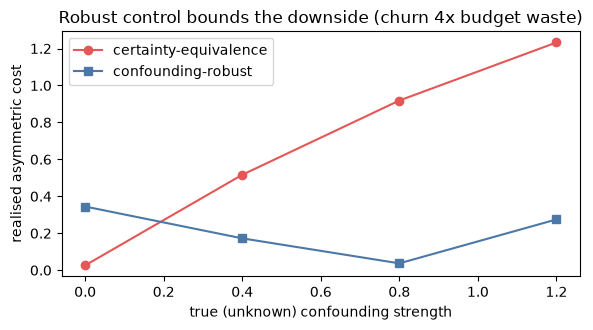

In [6]:
# Optional plot (needs the `viz` group: uv sync --group viz). Text table above works without it.
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.plot(curve.confounding_levels, curve.ce_costs, "o-", color="#E45756", label="certainty-equivalence")
    ax.plot(curve.confounding_levels, curve.robust_costs, "s-", color="#4C78A8", label="confounding-robust")
    ax.set_xlabel("true (unknown) confounding strength")
    ax.set_ylabel("realised asymmetric cost")
    ax.set_title("Robust control bounds the downside (churn 4x budget waste)")
    ax.legend()
    fig.tight_layout()
except ModuleNotFoundError:
    print("(install the `viz` group for the plot: uv sync --group viz)")

## Honest caveats

- `Gamma` is the analyst's **unfalsifiable** sensitivity input; a single scalar aggregates over
  covariates. These methods robustify *pessimism*, they do **not** test for confounding.
- The CVaR-gap → `b_hat` calibration is a *benchmark* assumption, not a general consequence of §32;
  the sign-identification constraint `b_hat > D > 0` must hold.
- `Result 37` is a synthetic *observational* task (the action follows the confounder); a genuine
  randomised switchback would reduce or remove the bias and is a natural experimental baseline.